# v6 Timing Models and Bound Animation

This lightweight companion to `system_303_solver_v6.ipynb` loads the saved snapshot archive; it does **not** repeat the expensive LP experiment.

It compares descriptive timing fits based on $m$, $m\log m$, $m^2$, and $m^3$, then animates the lower and upper bounds for coordinates congruent to 1 modulo 3. A constant timing model is included as a baseline.

The timed stage in v6 has the same LP dimensions at every snapshot: 300 zonotope variables, 600 intersection inequalities, one feasibility solve, and 600 extrema solves. Therefore these curves are empirical descriptions of instance difficulty, not asymptotic complexity estimates for the full algorithm. Basis selection and construction of $P_m$, $G_m$, $\widehat x_m$, $\Pi_m$, and $M$ were deliberately excluded from the recorded times.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation


results_path = Path("system_303_solver_v6_snapshot_results.npz")
data_path = Path("system_303")

if not results_path.exists():
    raise FileNotFoundError(
        f"Missing {results_path}. Run system_303_solver_v6.ipynb first."
    )

with np.load(results_path) as saved:
    snapshot_iterations = saved["m"].astype(int)
    snapshot_ranks = saved["rank"].astype(int)
    optimization_times = saved["optimization_time"].astype(float)
    l_history = saved["l_m"].astype(float)
    u_history = saved["u_m"].astype(float)

box = np.genfromtxt(data_path / "B0_wide_bc.dat", delimiter=",")
x_star_full = np.genfromtxt(data_path / "soln_x.dat")
l0_original = box[3:, 0]
u0_original = box[3:, 1]
x_star = x_star_full[3:]
n = l_history.shape[1]

if l_history.shape != u_history.shape:
    raise ValueError("Lower- and upper-bound histories have different shapes.")
if l_history.shape != (len(snapshot_iterations), n):
    raise ValueError("Snapshot metadata and enclosure histories are inconsistent.")

print(f"loaded {len(snapshot_iterations)} snapshots with {n} coordinates")
print(
    f"optimization time range: {optimization_times.min():.2f} to "
    f"{optimization_times.max():.2f} seconds"
)

loaded 52 snapshots with 300 coordinates
optimization time range: 5.34 to 184.88 seconds


## Compare descriptive timing models

For each candidate basis $g(m)$, fit $t=a+b\,g(m)$ by least squares. The table reports in-sample RMSE, leave-one-out cross-validation RMSE, $R^2$, and the fitted coefficient $b$. Since all non-constant candidates have two fitted parameters, their RMSE and cross-validation rankings are directly comparable.

A negative $b$ means the curve is decreasing and must **not** be interpreted as an $O(g(m))$ growth law.

In [2]:
m_values = snapshot_iterations.astype(float)
t_values = optimization_times

candidate_bases = {
    "constant": np.ones_like(m_values),
    "m": m_values,
    "m log m": m_values * np.log(m_values),
    "m^2": m_values**2,
    "m^3": m_values**3,
}


def fit_timing_model(label, raw_basis, times):
    """Fit a stable two-parameter model and compute LOOCV predictions."""
    if label == "constant":
        prediction = np.full_like(times, np.mean(times))
        loo_prediction = np.array(
            [np.mean(np.delete(times, i)) for i in range(len(times))]
        )
        intercept = float(np.mean(times))
        coefficient = 0.0
        parameter_count = 1
    else:
        basis_scale = float(np.max(np.abs(raw_basis)))
        normalized_basis = raw_basis / basis_scale
        design = np.column_stack((np.ones_like(normalized_basis), normalized_basis))
        beta = np.linalg.lstsq(design, times, rcond=None)[0]
        prediction = design @ beta
        intercept = float(beta[0])
        coefficient = float(beta[1] / basis_scale)
        parameter_count = 2

        loo_prediction = np.empty_like(times)
        for i in range(len(times)):
            keep = np.arange(len(times)) != i
            beta_loo = np.linalg.lstsq(design[keep], times[keep], rcond=None)[0]
            loo_prediction[i] = design[i] @ beta_loo

    residual = times - prediction
    rss = float(residual @ residual)
    tss = float(np.sum((times - np.mean(times)) ** 2))
    rmse = float(np.sqrt(np.mean(residual**2)))
    loocv_rmse = float(np.sqrt(np.mean((times - loo_prediction) ** 2)))
    r_squared = float(1.0 - rss / tss) if tss > 0 else np.nan
    aic = float(len(times) * np.log(rss / len(times)) + 2 * parameter_count)

    return {
        "label": label,
        "intercept": intercept,
        "coefficient": coefficient,
        "prediction": prediction,
        "rmse": rmse,
        "loocv_rmse": loocv_rmse,
        "r_squared": r_squared,
        "aic": aic,
    }


timing_fits = [
    fit_timing_model(label, basis, t_values)
    for label, basis in candidate_bases.items()
]
timing_fits.sort(key=lambda fit: fit["loocv_rmse"])
best_fit = timing_fits[0]
best_growth_fit = min(
    (fit for fit in timing_fits if fit["label"] != "constant"),
    key=lambda fit: fit["loocv_rmse"],
)

print(
    f"{'model':<12} {'LOOCV RMSE (s)':>16} {'RMSE (s)':>11} "
    f"{'R^2':>9} {'coefficient b':>17}"
)
print("-" * 70)
for fit in timing_fits:
    print(
        f"{fit['label']:<12} {fit['loocv_rmse']:>16.3f} "
        f"{fit['rmse']:>11.3f} {fit['r_squared']:>9.3f} "
        f"{fit['coefficient']:>17.6e}"
    )

print(f"\nbest cross-validated descriptive fit: {best_fit['label']}")
if best_growth_fit["coefficient"] <= 0:
    print(
        f"The best non-constant candidate is {best_growth_fit['label']}, but its "
        f"coefficient is negative ({best_growth_fit['coefficient']:.6e})."
    )
    print(
        "Conclusion: the optimization-stage measurements do not support an "
        "increasing m, m log m, m^2, or m^3 cost law."
    )

model          LOOCV RMSE (s)    RMSE (s)       R^2     coefficient b
----------------------------------------------------------------------
m                      23.667      22.064     0.203     -7.422824e-02
m log m                23.743      22.293     0.187     -1.101615e-02
m^2                    24.130      23.096     0.127     -1.072823e-04
m^3                    24.435      23.594     0.089     -1.794395e-07
constant               25.201      24.717    -0.000      0.000000e+00

best cross-validated descriptive fit: m
The best non-constant candidate is m, but its coefficient is negative (-7.422824e-02).
Conclusion: the optimization-stage measurements do not support an increasing m, m log m, m^2, or m^3 cost law.


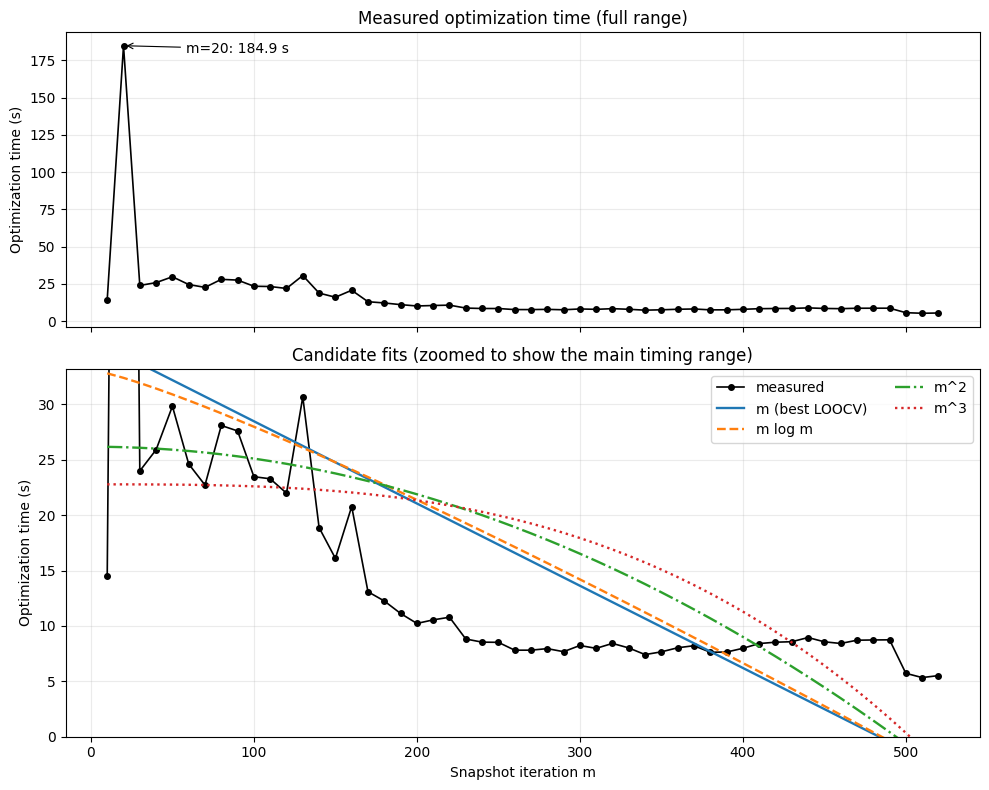

In [3]:
fit_by_label = {fit["label"]: fit for fit in timing_fits}
growth_labels = ["m", "m log m", "m^2", "m^3"]
line_styles = ["-", "--", "-.", ":"]

fig, (ax_full, ax_zoom) = plt.subplots(
    2, 1, figsize=(10, 8), sharex=True, gridspec_kw={"height_ratios": [1.0, 1.25]}
)

ax_full.plot(
    snapshot_iterations,
    optimization_times,
    color="black",
    marker="o",
    markersize=4,
    linewidth=1.2,
    label="measured",
)
largest_index = int(np.argmax(optimization_times))
ax_full.annotate(
    f"m={snapshot_iterations[largest_index]}: {optimization_times[largest_index]:.1f} s",
    xy=(snapshot_iterations[largest_index], optimization_times[largest_index]),
    xytext=(45, -5),
    textcoords="offset points",
    arrowprops={"arrowstyle": "->", "linewidth": 0.8},
)
ax_full.set_ylabel("Optimization time (s)")
ax_full.set_title("Measured optimization time (full range)")
ax_full.grid(alpha=0.25)

ax_zoom.plot(
    snapshot_iterations,
    optimization_times,
    color="black",
    marker="o",
    markersize=4,
    linewidth=1.2,
    label="measured",
)
for label, style in zip(growth_labels, line_styles):
    fit = fit_by_label[label]
    suffix = " (best LOOCV)" if label == best_growth_fit["label"] else ""
    ax_zoom.plot(
        snapshot_iterations,
        fit["prediction"],
        linestyle=style,
        linewidth=1.7,
        label=f"{label}{suffix}",
    )

zoom_ceiling = 1.15 * np.percentile(optimization_times, 95)
ax_zoom.set_ylim(0.0, zoom_ceiling)
ax_zoom.set_xlabel("Snapshot iteration m")
ax_zoom.set_ylabel("Optimization time (s)")
ax_zoom.set_title("Candidate fits (zoomed to show the main timing range)")
ax_zoom.grid(alpha=0.25)
ax_zoom.legend(ncol=2)

fig.tight_layout()
plt.show()

## Lower/upper-bound animation for coordinates 1 modulo 3

The first frame is the original box at $m=0$; subsequent frames use the 52 intersect-first enclosures. The animation controls provide play/pause and direct frame selection.

In [4]:
mod1_indices = np.arange(n)[np.arange(n) % 3 == 1]
animation_iterations = np.concatenate(([0], snapshot_iterations))
animation_lowers = np.vstack((l0_original, l_history))[:, mod1_indices]
animation_uppers = np.vstack((u0_original, u_history))[:, mod1_indices]

y_min = float(np.min(animation_lowers))
y_max = float(np.max(animation_uppers))
padding = 0.03 * max(y_max - y_min, 1.0)

fig, ax = plt.subplots(figsize=(10, 5.2))
lower_line, = ax.plot(
    mod1_indices, animation_lowers[0], linewidth=1.2, label="lower bound"
)
upper_line, = ax.plot(
    mod1_indices, animation_uppers[0], linewidth=1.2, label="upper bound"
)
x_star_points, = ax.plot(
    mod1_indices,
    x_star[mod1_indices],
    ".",
    color="black",
    markersize=3,
    label="x_star",
)
frame_label = ax.text(0.02, 0.95, "", transform=ax.transAxes, va="top")

ax.set_xlim(mod1_indices[0], mod1_indices[-1])
ax.set_ylim(y_min - padding, y_max + padding)
ax.set_xlabel("Coordinate index (1 mod 3)")
ax.set_ylabel("Bound value")
ax.set_title("Intersect-first lower and upper bounds over time")
ax.grid(alpha=0.25)
ax.legend()


def update_bounds(frame):
    lower_line.set_ydata(animation_lowers[frame])
    upper_line.set_ydata(animation_uppers[frame])
    frame_label.set_text(f"snapshot m={animation_iterations[frame]}")
    return lower_line, upper_line, x_star_points, frame_label


bounds_animation = FuncAnimation(
    fig,
    update_bounds,
    frames=len(animation_iterations),
    interval=220,
    blit=False,
)
display(HTML(bounds_animation.to_jshtml(fps=5, default_mode="once")))
plt.close(fig)

print(
    f"animation frames: {len(animation_iterations)} "
    f"(m={animation_iterations[0]} through m={animation_iterations[-1]})"
)

animation frames: 53 (m=0 through m=520)
